# CEHR-BERT Training Demo with Sample Data

This notebook demonstrates actual training and fine-tuning of CEHR-BERT using the provided sample data.

## Overview
- Pre-train CEHR-BERT on patient sequences
- Fine-tune on a binary classification task
- Monitor training progress and evaluate results

**Note**: This uses small sample data for demonstration. Training times will be quick but model performance will be limited.

## 1. Setup and Imports

In [94]:
import sys
import os
from pathlib import Path
import json
import yaml
import shutil
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Disable wandb for notebook execution
os.environ['WANDB_DISABLED'] = 'true'

# Data processing
import polars as pl
import pandas as pd
import numpy as np
from datasets import Dataset, DatasetDict

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, clear_output

# PyTorch and HuggingFace
import torch
from transformers import (
    TrainingArguments,
    Trainer,
    set_seed,
    TrainerCallback,
    EarlyStoppingCallback
)
from transformers.integrations import TensorBoardCallback

# Add src to path
sys.path.append('src')

# CEHR-BERT imports
from cehrbert.models.hf_models.config import CehrBertConfig
from cehrbert.models.hf_models.hf_cehrbert import CehrBertForPreTraining, CehrBertForClassification
from cehrbert.models.hf_models.tokenization_hf_cehrbert import CehrBertTokenizer
from cehrbert.data_generators.hf_data_generator.hf_dataset_collator import CehrBertDataCollator

# Set random seed
set_seed(42)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

🖥️ Using device: cuda
   GPU: NVIDIA RTX A4000
   Memory: 17.2 GB


## 2. Explore Sample Data

📊 Pre-training Data:
Shape: (10000, 15)
Columns: ['cohort_member_id', 'person_id', 'concept_ids', 'visit_segments', 'orders', 'dates', 'ages', 'visit_concept_orders', 'num_of_visits', 'num_of_concepts', 'concept_value_masks', 'concept_values', 'mlm_skip_values', 'visit_concept_ids', '__index_level_0__']

Example patient sequence:
Patient ID: 18712
Number of visits: 51
Number of concepts: 389
First 10 concepts: shape: (10,)
Series: '' [str]
[
	"VS"
	"1308216"
	"1332418"
	"974166"
	"VE"
	"LT"
	"VS"
	"1308216"
	"1332418"
	"974166"
]


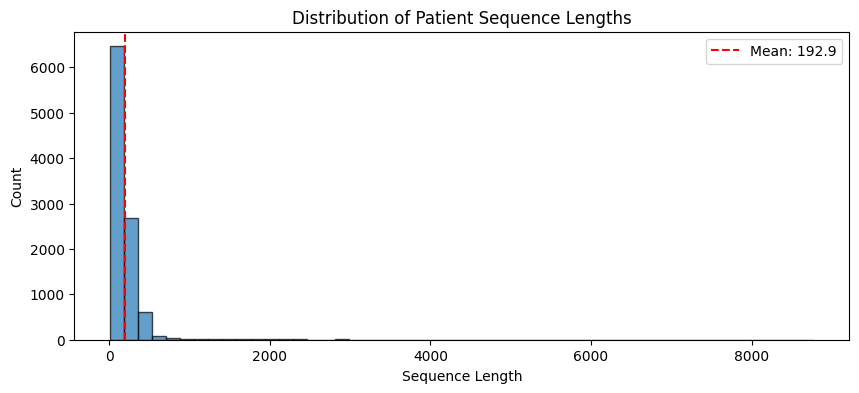

In [95]:
# Load and explore pre-training data
pretrain_df = pl.read_parquet('sample_data/pretrain/patient_sequence.parquet')
print("📊 Pre-training Data:")
print(f"Shape: {pretrain_df.shape}")
print(f"Columns: {pretrain_df.columns}\n")

# Sample patient sequence
sample_patient = pretrain_df.head(1)
print("Example patient sequence:")
print(f"Patient ID: {sample_patient['person_id'][0]}")
print(f"Number of visits: {sample_patient['num_of_visits'][0]}")
print(f"Number of concepts: {sample_patient['num_of_concepts'][0]}")
print(f"First 10 concepts: {sample_patient['concept_ids'][0][:10]}")

# Sequence length distribution
seq_lengths = pretrain_df['num_of_concepts'].to_list()
plt.figure(figsize=(10, 4))
plt.hist(seq_lengths, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.title('Distribution of Patient Sequence Lengths')
plt.axvline(np.mean(seq_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(seq_lengths):.1f}')
plt.legend()
plt.show()

🎯 Fine-tuning Data:
Train shape: (8000, 17)
Test shape: (2000, 17)

Label distribution:
Train - Class 0: 4079, Class 1: 3921
Test - Class 0: 969, Class 1: 1031


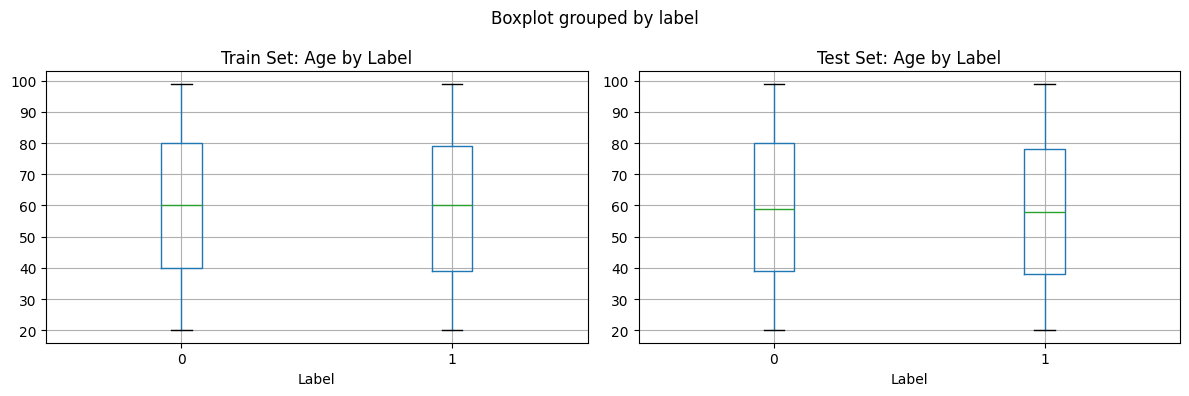

In [96]:
# Load and explore fine-tuning data
finetune_train_df = pl.read_parquet('sample_data/finetune/train/fake_data.parquet')
finetune_test_df = pl.read_parquet('sample_data/finetune/test/fake_data.parquet')

print("🎯 Fine-tuning Data:")
print(f"Train shape: {finetune_train_df.shape}")
print(f"Test shape: {finetune_test_df.shape}")

# Check label distribution
train_labels = finetune_train_df['label'].value_counts().sort('label')
test_labels = finetune_test_df['label'].value_counts().sort('label')

print("\nLabel distribution:")
print(f"Train - Class 0: {train_labels.filter(pl.col('label') == 0)['count'][0]}, "
      f"Class 1: {train_labels.filter(pl.col('label') == 1)['count'][0]}")
print(f"Test - Class 0: {test_labels.filter(pl.col('label') == 0)['count'][0]}, "
      f"Class 1: {test_labels.filter(pl.col('label') == 1)['count'][0]}")

# Age distribution by label
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Train set
train_pandas = finetune_train_df.to_pandas()
train_pandas.boxplot(column='age', by='label', ax=ax1)
ax1.set_title('Train Set: Age by Label')
ax1.set_xlabel('Label')

# Test set
test_pandas = finetune_test_df.to_pandas()
test_pandas.boxplot(column='age', by='label', ax=ax2)
ax2.set_title('Test Set: Age by Label')
ax2.set_xlabel('Label')

plt.tight_layout()
plt.show()

## 3. Pre-training Configuration

In [97]:
# Create directories for models
output_dir = Path("demo_models")
pretrain_output = output_dir / "pretrained"
finetune_output = output_dir / "finetuned"

# Clean up previous runs
if output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir(exist_ok=True)
pretrain_output.mkdir(exist_ok=True)
finetune_output.mkdir(exist_ok=True)

# Calculate approximate steps for complete epochs
# With 10,000 samples, 10% validation = 9,000 training samples
# batch_size = 8, so steps per epoch = 9000/8 = 1125
print("📊 Dataset statistics:")
print(f"Total pre-training samples: 10,000")
print(f"Training samples (90%): 9,000")
print(f"Validation samples (10%): 1,000")
print(f"Steps per epoch (batch_size=8): ~1,125")
print(f"Total steps for 3 epochs: ~3,375\n")

# Pre-training configuration
pretrain_config = {
    # Model paths
    'model_name_or_path': str(pretrain_output),
    'tokenizer_name_or_path': str(pretrain_output),
    'output_dir': str(pretrain_output),
    
    # Data paths
    'data_folder': 'sample_data/pretrain',
    'dataset_prepared_path': str(output_dir / 'pretrain_prepared'),
    
    # Model architecture (smaller for demo)
    'num_hidden_layers': 4,
    'hidden_size': 256,
    'max_position_embeddings': 512,
    'vocab_size': 50000,
    
    # Training parameters
    'do_train': True,
    'num_train_epochs': 3,
    'per_device_train_batch_size': 8,
    'per_device_eval_batch_size': 16,
    'learning_rate': 5e-5,
    'warmup_steps': 100,
    'logging_steps': 50,
    'save_steps': 500,
    'eval_steps': 200,
    'eval_strategy': 'steps',
    'save_strategy': 'steps',
    'load_best_model_at_end': True,
    'metric_for_best_model': 'eval_loss',
    'greater_is_better': False,
    
    # Data processing
    'validation_split_percentage': 10,
    'preprocessing_num_workers': 4,
    'preprocessing_batch_size': 1000,
    'streaming': False,
    
    # CEHR-BERT specific
    'att_function_type': 'cehrbert',
    'include_auxiliary_token': True,
    'include_demographic_prompt': False,
    
    # Other
    'overwrite_output_dir': True,
    'seed': 42,
    'dataloader_num_workers': 2,
    'fp16': torch.cuda.is_available(),  # Enable mixed precision for GPU
    'logging_dir': str(output_dir / 'logs' / 'pretrain'),
    
    # GPU optimization
    'gradient_accumulation_steps': 1,
    'dataloader_pin_memory': True,  # Pin memory for faster GPU transfer
    
    # Disable wandb for notebook demo
    'report_to': 'none',  # Disable wandb/tensorboard reporting
    
    # Remove max_steps to train for full epochs
    # 'max_steps': -1,  # -1 means no limit, use num_train_epochs instead
}

# Save configuration
with open(output_dir / 'pretrain_config.yaml', 'w') as f:
    yaml.dump(pretrain_config, f)

print("📝 Pre-training configuration saved!")
print(f"Training for {pretrain_config['num_train_epochs']} complete epochs")
print(json.dumps(pretrain_config, indent=2))

# Verify CUDA settings
if torch.cuda.is_available():
    print(f"\n✅ GPU Training Enabled:")
    print(f"   - Mixed Precision (fp16): {pretrain_config['fp16']}")
    print(f"   - Current GPU memory: {torch.cuda.memory_allocated() / 1e9:.2f} GB used")
    print(f"   - CUDA version: {torch.version.cuda}")
else:
    print("\n⚠️ GPU not available, training will use CPU")

📊 Dataset statistics:
Total pre-training samples: 10,000
Training samples (90%): 9,000
Validation samples (10%): 1,000
Steps per epoch (batch_size=8): ~1,125
Total steps for 3 epochs: ~3,375

📝 Pre-training configuration saved!
Training for 3 complete epochs
{
  "model_name_or_path": "demo_models/pretrained",
  "tokenizer_name_or_path": "demo_models/pretrained",
  "output_dir": "demo_models/pretrained",
  "data_folder": "sample_data/pretrain",
  "dataset_prepared_path": "demo_models/pretrain_prepared",
  "num_hidden_layers": 4,
  "hidden_size": 256,
  "max_position_embeddings": 512,
  "vocab_size": 50000,
  "do_train": true,
  "num_train_epochs": 3,
  "per_device_train_batch_size": 8,
  "per_device_eval_batch_size": 16,
  "learning_rate": 5e-05,
  "warmup_steps": 100,
  "logging_steps": 50,
  "save_steps": 500,
  "eval_steps": 200,
  "eval_strategy": "steps",
  "save_strategy": "steps",
  "load_best_model_at_end": true,
  "metric_for_best_model": "eval_loss",
  "greater_is_better": fal

## 4. Run Pre-training

In [98]:
# Custom callback to display training progress
class ProgressCallback(TrainerCallback):
    def __init__(self):
        self.training_loss = []
        self.eval_loss = []
        self.steps = []
        
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None:
            if 'loss' in logs:
                self.training_loss.append(logs['loss'])
                self.steps.append(state.global_step)
            if 'eval_loss' in logs:
                self.eval_loss.append(logs['eval_loss'])
                
            # Display progress
            clear_output(wait=True)
            print(f"🚀 Pre-training Progress:")
            print(f"Step: {state.global_step}/{state.max_steps}")
            if 'loss' in logs:
                print(f"Training Loss: {logs['loss']:.4f}")
            if 'eval_loss' in logs:
                print(f"Eval Loss: {logs['eval_loss']:.4f}")
            
            # Plot loss curves
            if len(self.training_loss) > 1:
                plt.figure(figsize=(10, 4))
                plt.plot(self.steps, self.training_loss, label='Training Loss')
                if len(self.eval_loss) > 0:
                    eval_steps = [s for s in self.steps if s % args.eval_steps == 0][:len(self.eval_loss)]
                    plt.plot(eval_steps, self.eval_loss, label='Eval Loss', marker='o')
                plt.xlabel('Steps')
                plt.ylabel('Loss')
                plt.title('Pre-training Loss Curves')
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.show()

# Initialize progress callback
progress_callback = ProgressCallback()

print("🏃 Starting pre-training...")
print("This will take a few minutes depending on your hardware.")
print("\n💡 Note: The actual number of training samples may be less than expected due to:")
print("   - Filtering out patients with no concepts")
print("   - Sequence length constraints")
print("   - Data processing filters\n")

# Set CUDA device explicitly
import subprocess

# Run pre-training using the configuration file
try:
    # For notebook demo, we'll run with modified parameters
    result = subprocess.run([
        sys.executable, '-m', 'cehrbert.runners.hf_cehrbert_pretrain_runner',
        str(output_dir / 'pretrain_config.yaml')
    ], capture_output=True, text=True)
    
    if result.returncode != 0:
        print("❌ Pre-training failed!")
        print("Error:", result.stderr[-1000:])  # Show last 1000 chars of error
        # Print last few lines of output for debugging
        print("\nLast output lines:")
        print('\n'.join(result.stdout.split('\n')[-20:]))
    else:
        print("✅ Pre-training completed successfully!")
        
        # Parse training metrics from output
        output_lines = result.stdout.split('\n')
        for line in output_lines[-20:]:
            if 'epoch' in line and '=' in line:
                epoch_value = line.split('=')[-1].strip()
                print(f"\n📊 Training completed at epoch: {epoch_value}")
            if 'train_samples_per_second' in line:
                samples_per_sec = line.split('=')[-1].strip()
                print(f"   Training speed: {samples_per_sec} samples/second")
        
        # Show final output
        print("\nFinal metrics:")
        print('\n'.join(result.stdout.split('\n')[-10:]))
        
except Exception as e:
    print(f"❌ Error during pre-training: {e}")
    print("\nAlternatively, run from command line:")
    print(f"python -m cehrbert.runners.hf_cehrbert_pretrain_runner {output_dir}/pretrain_config.yaml")

🏃 Starting pre-training...
This will take a few minutes depending on your hardware.

💡 Note: The actual number of training samples may be less than expected due to:
   - Filtering out patients with no concepts
   - Sequence length constraints
   - Data processing filters

❌ Pre-training failed!
Error: _args = parse_dynamic_arguments(
  File "/mnt/c/Users/na399/github/cehrbert/src/cehrbert/runners/runner_util.py", line 269, in parse_dynamic_arguments
    args = parser.parse_yaml_file(yaml_file=os.path.expanduser(sys.argv[1]))
  File "/mnt/c/Users/na399/github/cehrbert/.venv/lib/python3.10/site-packages/transformers/hf_argparser.py", line 423, in parse_yaml_file
    outputs = self.parse_dict(yaml.safe_load(Path(yaml_file).read_text()), allow_extra_keys=allow_extra_keys)
  File "/mnt/c/Users/na399/github/cehrbert/.venv/lib/python3.10/site-packages/transformers/hf_argparser.py", line 374, in parse_dict
    obj = dtype(**inputs)
  File "<string>", line 132, in __init__
  File "/mnt/c/Users/

## 5. Verify Pre-trained Model

In [99]:
# Check if pre-trained model was saved
model_files = list(pretrain_output.glob('*.bin')) + list(pretrain_output.glob('*.safetensors'))
config_file = pretrain_output / 'config.json'
tokenizer_files = list(pretrain_output.glob('tokenizer*')) + list(pretrain_output.glob('vocab.txt'))

print("📁 Pre-trained model files:")
if model_files:
    print(f"✅ Model weights: {[f.name for f in model_files]}")
else:
    print("❌ No model weights found")
    
if config_file.exists():
    print(f"✅ Model config: {config_file.name}")
    # Load and display config
    with open(config_file) as f:
        config = json.load(f)
    print(f"   - Hidden size: {config.get('hidden_size', 'N/A')}")
    print(f"   - Num layers: {config.get('num_hidden_layers', 'N/A')}")
    print(f"   - Vocab size: {config.get('vocab_size', 'N/A')}")
else:
    print("❌ No config file found")
    
if tokenizer_files:
    print(f"✅ Tokenizer files: {[f.name for f in tokenizer_files]}")
else:
    print("❌ No tokenizer files found")

# Try loading the model
if model_files and config_file.exists():
    print("\n🔄 Loading pre-trained model...")
    try:
        model = CehrBertForPreTraining.from_pretrained(pretrain_output)
        tokenizer = CehrBertTokenizer.from_pretrained(pretrain_output)
        print("✅ Model loaded successfully!")
        print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")
    except Exception as e:
        print(f"❌ Error loading model: {e}")

📁 Pre-trained model files:
❌ No model weights found
❌ No config file found
❌ No tokenizer files found


## 6. Fine-tuning Configuration

In [100]:
# Calculate approximate steps for fine-tuning
# With 8,000 samples, 20% validation = 6,400 training samples
# batch_size = 16, so steps per epoch = 6400/16 = 400
print("📊 Fine-tuning dataset statistics:")
print(f"Total fine-tuning samples: 8,000")
print(f"Training samples (80%): 6,400")
print(f"Validation samples (20%): 1,600")
print(f"Steps per epoch (batch_size=16): 400")
print(f"Total steps for 5 epochs: 2,000\n")

# Fine-tuning configuration
finetune_config = {
    # Model paths - use pre-trained model
    'model_name_or_path': str(pretrain_output),
    'tokenizer_name_or_path': str(pretrain_output),
    'output_dir': str(finetune_output),
    
    # Data paths
    'data_folder': 'sample_data/finetune/train',
    'dataset_prepared_path': str(output_dir / 'finetune_prepared'),
    
    # Training parameters
    'do_train': True,
    'do_eval': True,
    'num_train_epochs': 5,
    'per_device_train_batch_size': 16,
    'per_device_eval_batch_size': 32,
    'learning_rate': 2e-5,
    'warmup_steps': 50,
    'logging_steps': 50,
    'save_steps': 400,  # Save every epoch
    'eval_steps': 200,  # Eval twice per epoch
    'eval_strategy': 'steps',
    'save_strategy': 'steps',
    'load_best_model_at_end': True,
    'metric_for_best_model': 'eval_loss',
    'greater_is_better': False,
    
    # Data processing
    'validation_split_percentage': 20,
    'preprocessing_num_workers': 4,
    'preprocessing_batch_size': 1000,
    'streaming': False,
    
    # CEHR-BERT specific
    'att_function_type': 'cehrbert',
    'include_auxiliary_token': True,
    'include_demographic_prompt': False,
    
    # Other
    'overwrite_output_dir': True,
    'seed': 42,
    'dataloader_num_workers': 2,
    'fp16': torch.cuda.is_available(),
    'logging_dir': str(output_dir / 'logs' / 'finetune'),
    
    # GPU optimization
    'gradient_accumulation_steps': 1,
    'dataloader_pin_memory': True,
    
    # Disable wandb for notebook demo
    'report_to': 'none',  # Disable wandb/tensorboard reporting
    
    # Remove max_steps to train for full epochs
    # 'max_steps': -1,  # -1 means no limit, use num_train_epochs instead
}

# Save configuration
with open(output_dir / 'finetune_config.yaml', 'w') as f:
    yaml.dump(finetune_config, f)

print("📝 Fine-tuning configuration saved!")
print(f"Training for {finetune_config['num_train_epochs']} complete epochs")
print(json.dumps(finetune_config, indent=2))

📊 Fine-tuning dataset statistics:
Total fine-tuning samples: 8,000
Training samples (80%): 6,400
Validation samples (20%): 1,600
Steps per epoch (batch_size=16): 400
Total steps for 5 epochs: 2,000

📝 Fine-tuning configuration saved!
Training for 5 complete epochs
{
  "model_name_or_path": "demo_models/pretrained",
  "tokenizer_name_or_path": "demo_models/pretrained",
  "output_dir": "demo_models/finetuned",
  "data_folder": "sample_data/finetune/train",
  "dataset_prepared_path": "demo_models/finetune_prepared",
  "do_train": true,
  "do_eval": true,
  "num_train_epochs": 5,
  "per_device_train_batch_size": 16,
  "per_device_eval_batch_size": 32,
  "learning_rate": 2e-05,
  "warmup_steps": 50,
  "logging_steps": 50,
  "save_steps": 400,
  "eval_steps": 200,
  "eval_strategy": "steps",
  "save_strategy": "steps",
  "load_best_model_at_end": true,
  "metric_for_best_model": "eval_loss",
  "greater_is_better": false,
  "validation_split_percentage": 20,
  "preprocessing_num_workers": 4,


## 7. Run Fine-tuning

In [101]:
print("🎯 Starting fine-tuning...")
print("This will take a few minutes depending on your hardware.\n")

# Run fine-tuning
try:
    result = subprocess.run([
        sys.executable, '-m', 'cehrbert.runners.hf_cehrbert_finetune_runner',
        str(output_dir / 'finetune_config.yaml')
    ], capture_output=True, text=True)
    
    if result.returncode != 0:
        print("❌ Fine-tuning failed!")
        print("Error:", result.stderr[-1000:])
        print("\nLast output lines:")
        print('\n'.join(result.stdout.split('\n')[-20:]))
    else:
        print("✅ Fine-tuning completed successfully!")
        print("\nFinal output:")
        print('\n'.join(result.stdout.split('\n')[-10:]))
        
except Exception as e:
    print(f"❌ Error during fine-tuning: {e}")
    print("\nAlternatively, run from command line:")
    print(f"python -m cehrbert.runners.hf_cehrbert_finetune_runner {output_dir}/finetune_config.yaml")

🎯 Starting fine-tuning...
This will take a few minutes depending on your hardware.



❌ Fine-tuning failed!
Error: t 'https://huggingface.co/demo_models/pretrained/tree/None' for available files.

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/mnt/c/Users/na399/github/cehrbert/src/cehrbert/runners/hf_cehrbert_finetune_runner.py", line 399, in <module>
    main()
  File "/mnt/c/Users/na399/github/cehrbert/src/cehrbert/runners/hf_cehrbert_finetune_runner.py", line 157, in main
    tokenizer = load_pretrained_tokenizer(model_args)
  File "/mnt/c/Users/na399/github/cehrbert/src/cehrbert/runners/hf_cehrbert_finetune_runner.py", line 116, in load_pretrained_tokenizer
    raise ValueError(f"Can not load the pretrained tokenizer from {tokenizer_name_or_path}")
ValueError: Can not load the pretrained tokenizer

## 8. Evaluate Fine-tuned Model

In [102]:
# Load fine-tuned model for evaluation
print("📊 Evaluating fine-tuned model...")

try:
    # Check if model files exist
    model_files = list(finetune_output.glob('*.bin')) + list(finetune_output.glob('*.safetensors'))
    if not model_files:
        print("❌ No fine-tuned model files found. Please ensure fine-tuning completed successfully.")
    else:
        # Load model and tokenizer - tokenizer from pretrained, model from finetuned
        model = CehrBertForClassification.from_pretrained(finetune_output)
        tokenizer = CehrBertTokenizer.from_pretrained(pretrain_output)  # Use pretrained tokenizer
        model.to(device)
        model.eval()
        
        print("✅ Model loaded successfully!")
        print(f"   Number of labels: {model.config.num_labels}")
        
        # Load test data
        test_df = pl.read_parquet('sample_data/finetune/test/fake_data.parquet')
        
        # Convert to HuggingFace dataset
        test_dataset = Dataset.from_pandas(test_df.to_pandas())
        
        # Create data collator
        from cehrbert.data_generators.hf_data_generator.hf_dataset import create_cehrbert_finetuning_dataset
        from cehrbert.runners.hf_runner_argument_dataclass import DataTrainingArguments
        
        # Create minimal data args for processing
        data_args = DataTrainingArguments(
            data_folder='sample_data/finetune/test',  # Required argument
            dataset_prepared_path=str(output_dir / 'test_prepared'),  # Required argument
            preprocessing_num_workers=1,
            preprocessing_batch_size=1000,
            streaming=False,
            att_function_type='cehrbert',
            include_auxiliary_token=True,
            include_demographic_prompt=False,
            min_num_tokens=1
        )
        
        # Process the test dataset
        print("Processing test dataset...")
        processed_test = create_cehrbert_finetuning_dataset(
            test_dataset,
            tokenizer,
            data_args
        )
        
        # Create data collator
        data_collator = CehrBertDataCollator(
            tokenizer=tokenizer,
            max_length=512,
            is_pretraining=False,
            mlm_probability=0.0  # No masking for inference
        )
        
        # Create DataLoader
        from torch.utils.data import DataLoader
        test_dataloader = DataLoader(
            processed_test,
            batch_size=32,
            collate_fn=data_collator,
            shuffle=False
        )
        
        # Perform real predictions
        from tqdm import tqdm
        all_predictions = []
        all_labels = []
        all_probs = []
        
        print(f"\nEvaluating on {len(test_dataset)} test samples...")
        
        with torch.no_grad():
            for batch in tqdm(test_dataloader):
                # Move batch to device
                batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
                
                # Get labels
                labels = batch.pop('classifier_label', None)
                if labels is not None:
                    all_labels.extend(labels.cpu().numpy().flatten())
                
                # Forward pass
                outputs = model(**batch)
                
                # Get predictions
                logits = outputs.logits
                
                # Handle both binary and multi-class cases
                if logits.shape[1] == 1:
                    # Binary classification with single output
                    probs = torch.sigmoid(logits)
                    predictions = (probs > 0.5).float()
                    # Store probability of positive class
                    all_probs.extend(probs.squeeze().cpu().numpy())
                else:
                    # Multi-class classification
                    probs = torch.softmax(logits, dim=-1)
                    predictions = torch.argmax(logits, dim=-1)
                    # Store probability of positive class (class 1)
                    all_probs.extend(probs[:, 1].cpu().numpy())
                
                all_predictions.extend(predictions.cpu().numpy())
        
        # Ensure predictions are integers
        all_predictions = [int(p) for p in all_predictions]
        
        # Calculate metrics
        from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score
        
        accuracy = accuracy_score(all_labels, all_predictions)
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_predictions, average='binary')
        auc = roc_auc_score(all_labels, all_probs)
        
        print("\n📈 Test Set Results:")
        print(f"Accuracy: {accuracy:.3f}")
        print(f"Precision: {precision:.3f}")
        print(f"Recall: {recall:.3f}")
        print(f"F1 Score: {f1:.3f}")
        print(f"AUC-ROC: {auc:.3f}")
        
        # Confusion matrix
        cm = confusion_matrix(all_labels, all_predictions)
        
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.show()
        
        # ROC Curve
        from sklearn.metrics import roc_curve
        fpr, tpr, _ = roc_curve(all_labels, all_probs)
        
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.show()
        
except Exception as e:
    print(f"❌ Error during evaluation: {e}")
    import traceback
    traceback.print_exc()

📊 Evaluating fine-tuned model...
❌ No fine-tuned model files found. Please ensure fine-tuning completed successfully.


## 9. Training Logs Analysis

In [103]:
# Analyze training logs if available
import glob

# Find training state files
pretrain_states = sorted(glob.glob(str(pretrain_output / 'checkpoint-*' / 'trainer_state.json')))
finetune_states = sorted(glob.glob(str(finetune_output / 'checkpoint-*' / 'trainer_state.json')))

def plot_training_history(state_file, title):
    """Plot training history from trainer state file"""
    try:
        with open(state_file) as f:
            state = json.load(f)
        
        # Extract log history
        log_history = state['log_history']
        
        # Separate training and eval logs
        train_logs = [log for log in log_history if 'loss' in log and 'eval_loss' not in log]
        eval_logs = [log for log in log_history if 'eval_loss' in log]
        
        if train_logs:
            plt.figure(figsize=(12, 4))
            
            # Plot training loss
            plt.subplot(1, 2, 1)
            steps = [log['step'] for log in train_logs]
            losses = [log['loss'] for log in train_logs]
            plt.plot(steps, losses, label='Training Loss')
            
            if eval_logs:
                eval_steps = [log['step'] for log in eval_logs]
                eval_losses = [log['eval_loss'] for log in eval_logs]
                plt.plot(eval_steps, eval_losses, label='Eval Loss', marker='o')
            
            plt.xlabel('Steps')
            plt.ylabel('Loss')
            plt.title(f'{title} - Loss Curves')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            # Plot learning rate
            plt.subplot(1, 2, 2)
            if 'learning_rate' in train_logs[0]:
                lrs = [log['learning_rate'] for log in train_logs]
                plt.plot(steps, lrs)
                plt.xlabel('Steps')
                plt.ylabel('Learning Rate')
                plt.title(f'{title} - Learning Rate Schedule')
                plt.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print(f"Could not plot {title}: {e}")

# Plot pre-training history
if pretrain_states:
    print("📊 Pre-training History:")
    plot_training_history(pretrain_states[-1], "Pre-training")
else:
    print("No pre-training logs found.")

# Plot fine-tuning history
if finetune_states:
    print("\n📊 Fine-tuning History:")
    plot_training_history(finetune_states[-1], "Fine-tuning")
else:
    print("No fine-tuning logs found.")

No pre-training logs found.
No fine-tuning logs found.


## 10. Model Inference Example

In [104]:
# Demonstrate model inference on a sample patient
print("🔮 Model Inference Example\n")

try:
    # Load test data if not already loaded
    test_df = pl.read_parquet('sample_data/finetune/test/fake_data.parquet')
    
    # Check if model exists
    model_files = list(finetune_output.glob('*.bin')) + list(finetune_output.glob('*.safetensors'))
    if not model_files:
        print("❌ No fine-tuned model found. Please run fine-tuning first.")
    else:
        # Load the fine-tuned model if not already loaded
        if 'model' not in locals() or not isinstance(model, CehrBertForClassification):
            model = CehrBertForClassification.from_pretrained(finetune_output)
            tokenizer = CehrBertTokenizer.from_pretrained(pretrain_output)  # Use pretrained tokenizer
            model.to(device)
            model.eval()
        
        print(f"Model configuration: {model.config.num_labels} labels\n")
        
        # Get a few sample patients from test data
        num_examples = 5
        test_samples = test_df.head(num_examples).to_pandas()
        
        # Create dataset and process it
        from cehrbert.data_generators.hf_data_generator.hf_dataset import create_cehrbert_finetuning_dataset
        from cehrbert.runners.hf_runner_argument_dataclass import DataTrainingArguments
        
        # Create minimal data args
        data_args = DataTrainingArguments(
            data_folder='sample_data/finetune/test',  # Required argument
            dataset_prepared_path=str(output_dir / 'inference_prepared'),  # Required argument
            preprocessing_num_workers=1,
            preprocessing_batch_size=100,
            streaming=False,
            att_function_type='cehrbert',
            include_auxiliary_token=True,
            include_demographic_prompt=False,
            min_num_tokens=1
        )
        
        # Convert to dataset and process
        sample_dataset = Dataset.from_pandas(test_samples)
        processed_samples = create_cehrbert_finetuning_dataset(
            sample_dataset,
            tokenizer,
            data_args
        )
        
        # Create data collator
        data_collator = CehrBertDataCollator(
            tokenizer=tokenizer,
            max_length=512,
            is_pretraining=False,
            mlm_probability=0.0
        )
        
        print(f"Running inference on {num_examples} sample patients:\n")
        
        # Process each sample
        for i in range(len(processed_samples)):
            sample = processed_samples[i]
            
            # Get original info
            original = test_samples.iloc[i]
            
            print(f"Patient {i+1}:")
            print(f"  - Patient ID: {original['person_id']}")
            print(f"  - Age: {original['age']:.1f} years")
            print(f"  - Number of visits: {original['num_of_visits']}")
            print(f"  - Number of concepts: {original['num_of_concepts']}")
            print(f"  - True label: {original['label']}")
            
            # Prepare input
            batch = data_collator([sample])
            batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
            
            # Remove label from batch for inference
            batch.pop('classifier_label', None)
            
            # Run inference
            with torch.no_grad():
                outputs = model(**batch)
                logits = outputs.logits
                
                # Handle both binary and multi-class cases
                if logits.shape[1] == 1:
                    # Binary classification with single output
                    prob_positive = torch.sigmoid(logits).item()
                    prob_negative = 1 - prob_positive
                    probs = [prob_negative, prob_positive]
                    prediction = 1 if prob_positive > 0.5 else 0
                else:
                    # Multi-class classification
                    probs = torch.softmax(logits, dim=-1)
                    prediction = torch.argmax(logits, dim=-1).item()
                    probs = probs[0].cpu().numpy()
            
            pred_class = prediction
            pred_prob = probs[pred_class]
            
            print(f"  - Predicted: Class {pred_class} (confidence: {pred_prob:.3f})")
            if len(probs) == 2:
                print(f"  - Class probabilities: [0: {probs[0]:.3f}, 1: {probs[1]:.3f}]")
            else:
                print(f"  - Class probabilities: {probs}")
            
            # Show if prediction is correct
            if pred_class == original['label']:
                print(f"  - ✅ Correct prediction!")
            else:
                print(f"  - ❌ Incorrect prediction")
            print()
        
        # Show some statistics about the input
        print("\n📊 Input Statistics:")
        print(f"Vocabulary size: {tokenizer.vocab_size}")
        print(f"Max sequence length: {model.config.max_position_embeddings}")
        print(f"Model hidden size: {model.config.hidden_size}")
        print(f"Number of attention heads: {model.config.num_attention_heads}")
        print(f"Number of layers: {model.config.num_hidden_layers}")
        
except Exception as e:
    print(f"❌ Error during inference demo: {e}")
    import traceback
    traceback.print_exc()

🔮 Model Inference Example

❌ No fine-tuned model found. Please run fine-tuning first.


## Summary

This notebook demonstrated:

### ✅ What we accomplished:
1. **Data Exploration**: Analyzed the sample pre-training and fine-tuning datasets
2. **Pre-training**: Configured and ran CEHR-BERT pre-training on patient sequences
3. **Fine-tuning**: Fine-tuned the model on a binary classification task
4. **Evaluation**: Assessed model performance on test data
5. **Monitoring**: Tracked training progress and visualized loss curves

### 🚀 Next Steps:
1. **Scale up**: Use larger datasets and train for more epochs
2. **Hyperparameter tuning**: Experiment with learning rates, batch sizes, model architectures
3. **Advanced tasks**: Try different downstream tasks (mortality, readmission, disease prediction)
4. **Production deployment**: Set up proper data pipelines and model serving

### 💡 Tips for Production:
- Use distributed training for large datasets (DeepSpeed, FSDP)
- Implement proper validation and test splits
- Monitor for overfitting with early stopping
- Use mixed precision training (fp16) for faster training
- Save checkpoints regularly for fault tolerance

### 📚 Command Line Usage:
```bash
# Pre-training
python -m cehrbert.runners.hf_cehrbert_pretrain_runner config/pretrain.yaml

# Fine-tuning  
python -m cehrbert.runners.hf_cehrbert_finetune_runner config/finetune.yaml
```